In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

In [2]:
arena_mask = np.array([
    [-1, -1, -1,  0,  1],
    [ 2,  3,  4,  5,  6],
    [ 7,  8,  9, 10, 11],
    [-1, -1, -1, 12, 13]
])

def map_coordinates_to_cell(x, y, x_min, x_max, y_min, y_max):
    n_rows = 4
    n_cols = 5
    

    x_norm = np.clip((x - x_min) / (x_max - x_min), 0, 0.999)
    y_norm = np.clip((y - y_min) / (y_max - y_min), 0, 0.999)
    
    col_idx = int(np.floor(x_norm * n_cols))
    row_idx = int(np.floor(y_norm * n_rows))
    
    cell_id = arena_mask[row_idx, col_idx]
     
    if cell_id == -1:
        return np.nan 
    return cell_id

In [13]:
mice = [i for i in range(13, 21)]

mouse_num = mice[2]
day = 1
day_num = day + 7
df = pd.read_csv(f'./dlc/dlc/d{day_num}_m{mouse_num}_investigation_cropped.csv', index_col=0)

confidence_threshold = 0.8
df = df[df['Center_p'] > confidence_threshold]

df.head()

,Ear_left_x,Ear_left_y,Ear_left_p,Ear_right_x,Ear_right_y,Ear_right_p,Nose_x,Nose_y,Nose_p,Center_x,...,Corridor Animal_1 in zone_cumulative_percent,Shelter Animal_1 in zone,Shelter Animal_1 in zone_cumulative_time,Shelter Animal_1 in zone_cumulative_percent,Chamber Animal_1 distance,Corridor Animal_1 distance,Shelter Animal_1 distance,Chamber Animal_1 facing,Corridor Animal_1 facing,Shelter Animal_1 facing
0,142.00000,308.00000,0.999319,137.00000,337.00000,0.999712,154.00000,326.00000,0.998135,93.000000,...,1.0,1,0.04,1.0,684.0029,239.47025,318.24677,1,1,0
1,143.00000,308.00000,0.999287,137.00000,337.00000,0.999666,153.00000,328.00000,0.995415,92.000000,...,1.0,1,0.08,1.0,684.3486,240.46829,319.00156,1,1,0
2,143.60402,309.81207,0.998731,137.19205,337.79608,0.999707,151.37997,328.62003,0.995707,92.796074,...,1.0,1,0.12,1.0,684.6402,239.71233,318.00440,1,1,0
3,144.39598,310.61590,0.998559,137.39598,338.20392,0.999707,150.57616,329.59990,0.995047,92.807950,...,1.0,1,0.16,1.0,684.8276,239.71384,317.86185,1,1,0
4,145.19205,311.39597,0.998493,137.60402,338.60403,0.999720,150.19205,330.19205,0.994770,93.000000,...,1.0,1,0.20,1.0,684.9416,239.53497,317.59094,1,1,0


In [14]:
min_x, max_x = df['Center_x'].min(), df['Center_x'].max()
min_y, max_y = df['Center_y'].min(), df['Center_y'].max()
width = max_x - min_x
height = max_y - min_y
aspect_ratio = height / width

print(f"Arena Dimensions: W={width:.1f}, H={height:.1f}")
print(f"Aspect Ratio (H/W): {aspect_ratio:.3f}")

n_rows = 5
n_cols = int(np.round(n_rows / aspect_ratio))

print(f'grid shape: ({n_rows} x {n_cols})')

Arena Dimensions: W=1043.0, H=365.5
Aspect Ratio (H/W): 0.350
grid shape: (5 x 14)


In [16]:
for mouse in mice:
    mouse_num = mouse
    day = 1
    day_num = day + 7
    df = pd.read_csv(f'./dlc/dlc/d{day_num}_m{mouse_num}_investigation_cropped.csv', index_col=0)

    confidence_threshold = 0.8
    df = df[df['Center_p'] > confidence_threshold]

    min_x, max_x = df['Center_x'].min(), df['Center_x'].max()
    min_y, max_y = df['Center_y'].min(), df['Center_y'].max()
    width = max_x - min_x
    height = max_y - min_y
    aspect_ratio = height / width

    # print(f"Arena Dimensions: W={width:.1f}, H={height:.1f}")
    # print(f"Aspect Ratio (H/W): {aspect_ratio:.3f}")

    n_rows = 5
    n_cols = int(np.round(n_rows / aspect_ratio))

    print(f'Mouse {mouse}: ({n_rows} x {n_cols})')

Mouse 13: (5 x 15)
Mouse 14: (5 x 13)
Mouse 15: (5 x 14)
Mouse 16: (5 x 13)
Mouse 17: (5 x 14)
Mouse 18: (5 x 14)
Mouse 19: (5 x 14)
Mouse 20: (5 x 14)


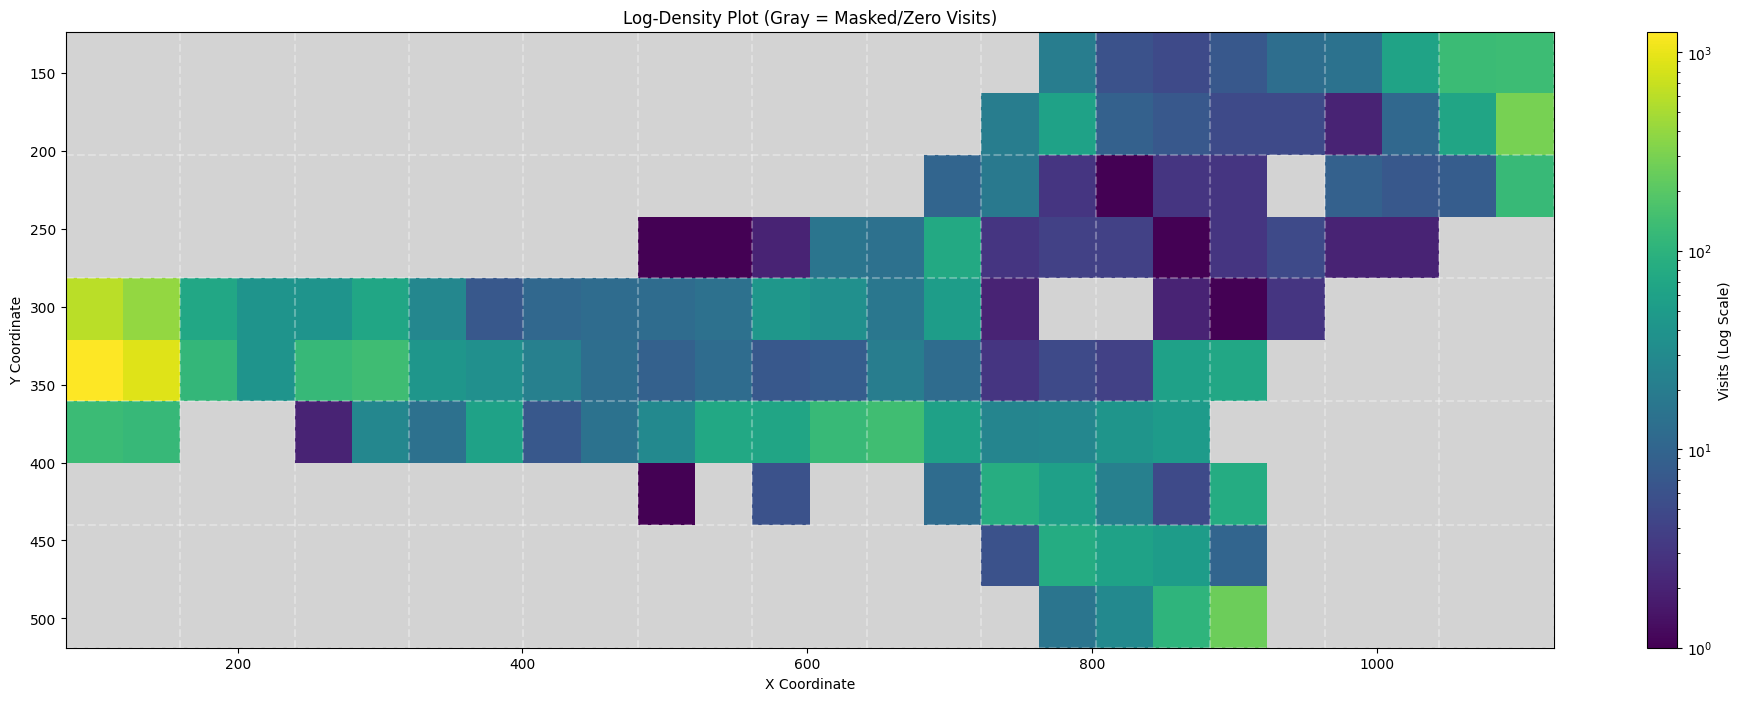

In [11]:
plt.figure(figsize=(24, 8))
ax = plt.gca()
ax.set_facecolor('lightgray') 


counts, xedges, yedges, image = plt.hist2d(
    df['Center_x'], df['Center_y'], 
    bins=[n_cols*2, n_rows*2],
    norm=colors.LogNorm(),
    cmap='viridis',
    cmin=1
)


x_grid = np.linspace(df['Center_x'].min(), df['Center_x'].max(), n_cols + 1)
y_grid = np.linspace(df['Center_y'].min(), df['Center_y'].max(), n_rows + 1)

for x in x_grid:
    plt.axvline(x, color='white', linestyle='--', alpha=0.3)
for y in y_grid:
    plt.axhline(y, color='white', linestyle='--', alpha=0.3)

%matplotlib inline
plt.colorbar(image, label='Visits (Log Scale)')
plt.gca().invert_yaxis()
plt.title(f"Log-Density Plot (Gray = Masked/Zero Visits)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.show()

In [12]:
mask = np.zeros((n_rows, n_cols), dtype=int)
for _, row in df.iterrows():
    c = int((row['Center_x'] - min_x) / (max_x - min_x) * n_cols)
    r = int((row['Center_y'] - min_y) / (max_y - min_y) * n_rows)
    # Clip to be safe
    c = min(max(c, 0), n_cols - 1)
    r = min(max(r, 0), n_rows - 1)
    mask[r, c] = 1

mask

array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0]])

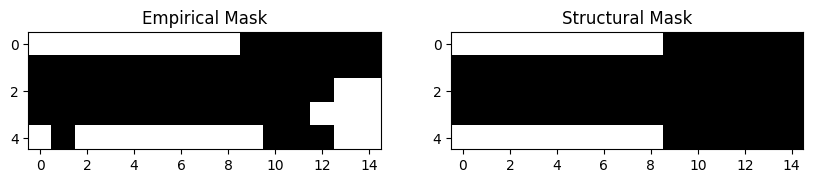


--- FINAL CLEAN MASK ---
[[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]]


In [ ]:
final_mask = mask.copy()
final_mask[4, 1] = 0
final_mask[0:5, 9:15] = 1

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Empirical Mask")
plt.imshow(mask, cmap='Greys')
plt.subplot(1, 2, 2)
plt.title("Structural Mask")
plt.imshow(final_mask, cmap='Greys')
plt.show()

print(final_mask)